In [2]:

#       "Potato Leaf Disease Detection using Image Classification"


#Project Description
#This project focuses on building an image classification model to detect and classify potato plantdiseases.
# The dataset consists of high-resolution images of potato leaves categorized into three classes: Early Blight, Late Blight, and Healthy leaves.
# The goal is to develop a robust deep learning model that can accurately identify plant diseases and support agricultural diagnostics.





#   Install & Import Libraries- step 1

!pip install kagglehub
!pip install tensorflow matplotlib seaborn scikit-learn

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix



Using Colab cache for faster access to the 'potato-plant-diseases-data' dataset.
Dataset path: /kaggle/input/potato-plant-diseases-data


In [3]:
#Load Dataset from Kaggle- step 2

import kagglehub

# Download dataset
path = kagglehub.dataset_download("hafiznouman786/potato-plant-diseases-data")

print("Dataset path:", path)

Using Colab cache for faster access to the 'potato-plant-diseases-data' dataset.
Dataset path: /kaggle/input/potato-plant-diseases-data


In [4]:
#Explore Dataset - step 3

for root, dirs, files in os.walk(path):
    print("Folder:", root)
    print("Number of images:", len(files))
    print("-"*30)

Folder: /kaggle/input/potato-plant-diseases-data
Number of images: 0
------------------------------
Folder: /kaggle/input/potato-plant-diseases-data/PlantVillage
Number of images: 0
------------------------------
Folder: /kaggle/input/potato-plant-diseases-data/PlantVillage/PlantVillage
Number of images: 0
------------------------------
Folder: /kaggle/input/potato-plant-diseases-data/PlantVillage/PlantVillage/Potato___healthy
Number of images: 152
------------------------------
Folder: /kaggle/input/potato-plant-diseases-data/PlantVillage/PlantVillage/Potato___Late_blight
Number of images: 1000
------------------------------
Folder: /kaggle/input/potato-plant-diseases-data/PlantVillage/PlantVillage/Potato___Early_blight
Number of images: 1000
------------------------------
Folder: /kaggle/input/potato-plant-diseases-data/PotatoPlants
Number of images: 0
------------------------------
Folder: /kaggle/input/potato-plant-diseases-data/PotatoPlants/Potato___healthy
Number of images: 152
-

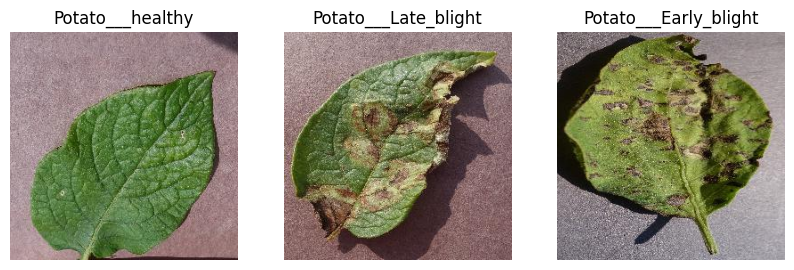

In [6]:
import random
from tensorflow.keras.preprocessing.image import load_img

# Correcting the base path to where the actual image class directories are located
# Based on the os.walk output, the image classes are under 'PlantVillage/PlantVillage'
image_base_path = os.path.join(path, 'PlantVillage', 'PlantVillage')

# List the actual disease classes
classes = os.listdir(image_base_path)

plt.figure(figsize=(10,5))

# Filter out any non-directory files or unwanted items from classes list, if any.
# In this specific case, os.listdir(image_base_path) should give us 'Potato___healthy', etc.

for i, cls in enumerate(classes):
    class_dir = os.path.join(image_base_path, cls)
    # Ensure it's a directory before trying to list its contents
    if os.path.isdir(class_dir):
        # Get a random image from the current class directory
        random_image_filename = random.choice(os.listdir(class_dir))
        img_path = os.path.join(class_dir, random_image_filename)

        img = load_img(img_path)

        plt.subplot(1, len(classes), i+1)
        plt.imshow(img)
        plt.title(cls)
        plt.axis("off")

plt.show()

In [11]:
#Data Preprocessing & Augmentation- step 5

img_size = (224, 224)
batch_size = 32

# Correcting the base path to where the actual image class directories are located
# Based on the os.walk output, the image classes are under 'PlantVillage/PlantVillage'
image_base_path = os.path.join(path, 'PlantVillage', 'PlantVillage')

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = datagen.flow_from_directory(
    image_base_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    image_base_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 1722 images belonging to 3 classes.
Found 430 images belonging to 3 classes.


In [8]:
#Build CNN Model - step 6

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(3, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
#Compile Model - step 7

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'],
    steps_per_execution=1
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Train Model - step 8

# Explicitly build the model before training to prevent ValueError related to tf.function
# The input shape is taken from the first batch of the training data generator
# Get a sample batch to infer the input shape
sample_batch = next(iter(train_data))
# The shape will be (batch_size, height, width, channels), we need (height, width, channels)
input_shape_for_build = sample_batch[0].shape[1:]
model.build(input_shape=(None,) + input_shape_for_build)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 291s 5s/step - accuracy: 0.6794 - loss: 0.7821 - val_accuracy: 0.8023 - val_loss: 0.4475
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 292s 5s/step - accuracy: 0.8432 - loss: 0.3748 - val_accuracy: 0.9093 - val_loss: 0.2752
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 280s 5s/step - accuracy: 0.8937 - loss: 0.2490 - val_accuracy: 0.8767 - val_loss: 0.3013
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 255s 5s/step - accuracy: 0.9286 - loss: 0.1818 - val_accuracy: 0.9535 - val_loss: 0.1151
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 249s 5s/step - accuracy: 0.9071 - loss: 0.2503 - val_accuracy: 0.9465 - val_loss: 0.1529
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 262s 5s/step - accuracy: 0.9373 - loss: 0.1781 - val_accuracy: 0.9535 - val_loss: 0.1287
Epoch 7/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 255s 5s/step - accuracy: 0.9472 - loss: 0.1473 - val_accuracy: 0.9581 - val_loss: 0.1296
Epoch 8/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 261s 5s/step - accuracy: 0.9611 - loss: 0.1076 - val_accuracy: 0.9628 - v

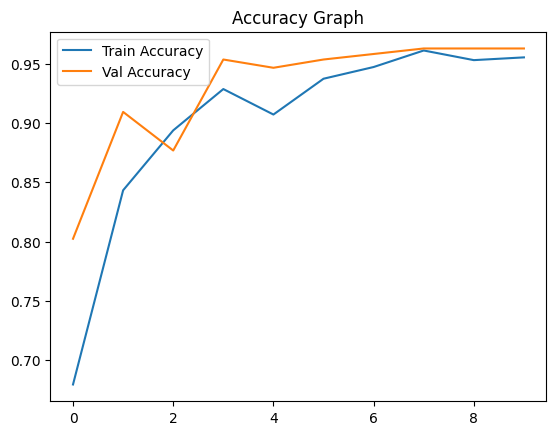

In [17]:
#Accuracy Graph - step 9

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.show()

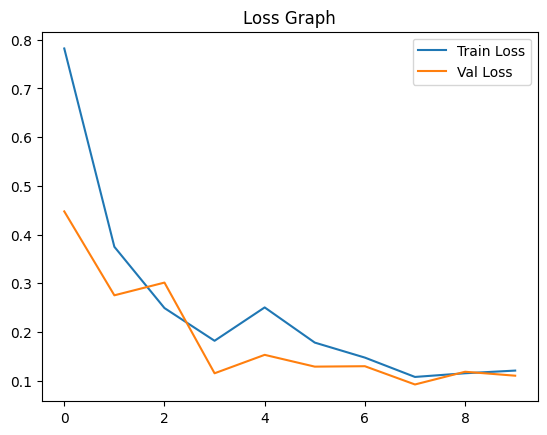

In [18]:
#Loss Graph - step 10

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss Graph")
plt.show()

In [20]:
#Model Evaluation - step 11

val_data.reset()
pred = model.predict(val_data)
y_pred = np.argmax(pred, axis=1)
y_true = val_data.classes

print(classification_report(y_true, y_pred))

14/14 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step
              precision    recall  f1-score   support

           0       0.47      0.44      0.45       200
           1       0.45      0.48      0.47       200
           2       0.08      0.07      0.07        30

    accuracy                           0.43       430
   macro avg       0.33      0.33      0.33       430
weighted avg       0.43      0.43      0.43       430



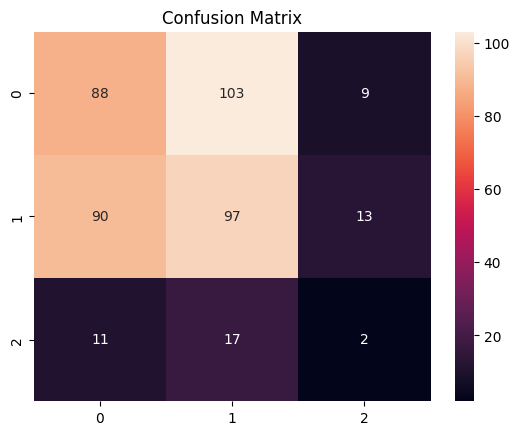

In [21]:
#Confusion Matrix - step 12

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [22]:
#Save Model - step 13

model.save("potato_disease_model.h5")